# M4 Final Project Draft
## NEISS Skiing and Snowboarding Injury Analysis (2016–2024)

### Project Objective
This project analyzes skiing and snowboarding injuries presenting to U.S. emergency departments using the National Electronic Injury Surveillance System (NEISS) dataset from 2016 to 2024. The primary goal is to compare injury patterns between skiing and snowboarding and identify demographic and injury characteristics associated with more severe outcomes.

### Research Questions
1. How do skiing and snowboarding injury patterns differ by age, sex, diagnosis, and injured body part?
2. Are there statistically significant differences in injury distributions between skiing and snowboarding?
3. What characteristics appear to be associated with more severe injury outcomes?

In [6]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

## Dataset Documentation (Data Card)

**Dataset Name:**  
National Electronic Injury Surveillance System (NEISS)

**Source:**  
U.S. Consumer Product Safety Commission (CPSC)

**Description:**  
The NEISS database is a nationally representative injury surveillance system that collects data from approximately 100 emergency departments across the United States. Each record represents a consumer product–related injury treated in a participating U.S. emergency department.

**Time Range Used in This Project:**  
2016–2024

**Population Represented:**  
Patients presenting to U.S. emergency departments with injuries related to skiing or snowboarding.

**Key Variables Used:**

| Variable | Description |
|--------|-------------|
| Age | Age of injured patient |
| Sex | Patient sex |
| Sport | Skiing or snowboarding indicator |
| Diagnosis | NEISS injury diagnosis code |
| Body_Part | Body region injured |
| Disposition | Patient outcome after ED visit |
| Year | Year of injury |

**Limitations of Dataset:**

- NEISS captures only injuries treated in emergency departments
- Does not capture injuries treated at urgent care or untreated injuries
- Limited clinical detail on injury severity
- Some coding variability between hospitals

**Ethical Considerations:**

- The dataset is fully de-identified
- No personally identifiable information is present
- Because this analysis uses observational cross-sectional data, results should be interpreted as descriptive associations rather than causal relationships.

## 1. Data Source and Loading

The dataset used in this project is derived from the U.S. Consumer Product Safety Commission (CPSC) National Electronic Injury Surveillance System (NEISS). NEISS is a nationally representative injury surveillance system that captures consumer product-related emergency department visits in the United States.

This project focuses on skiing and snowboarding injuries from 2016–2024. Each row in the dataset represents one emergency department visit.

In [7]:
#Load Dataset
path = "/Users/fchavez/Desktop/NEISS_V1_Comprehensive/neiss_snow_2016_2024_clean.csv"
df_raw = pd.read_csv(path)
df = df_raw.copy()

#Quick Structure check
print(df.shape)
display(df.head())
df.info()

(10317, 28)


,CPSC_Case_Number,Treatment_Date,Age,Sex,Race,Other_Race,Hispanic,Body_Part,Diagnosis,Other_Diagnosis,Body_Part_2,Diagnosis_2,Other_Diagnosis_2,Disposition,Location,Fire_Involvement,Alcohol,Drug,Product_1,Product_2,Product_3,Narrative_1,Stratum,PSU,Weight,Year,Sport,Age_Group
0,160103172,2016-01-01,39,1,1,NaN,NaN,79,59,NaN,NaN,NaN,NaN,1,9,0,NaN,NaN,3283,0,0,39YOM INJ.RT.SIDE BUTTOCK WHEN SNOW SKIING AT ...,S,28,87.7206,2016,Skiing,36-40
1,160105047,2016-01-03,21,2,1,NaN,NaN,34,57,NaN,NaN,NaN,NaN,1,9,0,NaN,NaN,5031,0,0,21YO F WAS SNOWBOARDING WHEN SHE FELL ONTO OUT...,L,89,72.8490,2016,Snowboarding,21-25
2,160106726,2016-01-01,25,1,0,NaN,NaN,30,55,NaN,NaN,NaN,NaN,1,9,0,NaN,NaN,5031,0,0,25YOM SNOWBOARDING FELL ONTO R SH: AC SEP R/SH...,V,67,16.1154,2016,Snowboarding,21-25
3,160106842,2016-01-01,46,1,0,NaN,NaN,30,55,NaN,NaN,NaN,NaN,1,9,0,NaN,NaN,3283,0,0,46YOM D'LOC SHLDR- FELL SNOW SKIING,V,17,16.1154,2016,Skiing,46-50
4,160109852,2016-01-02,33,1,0,NaN,NaN,30,55,NaN,NaN,NaN,NaN,1,9,0,NaN,NaN,5031,0,0,33YOM SNOWBOARDING FELL FLAT ONTO CLOSED SH ON...,V,67,16.1154,2016,Snowboarding,31-35


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10317 entries, 0 to 10316
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CPSC_Case_Number   10317 non-null  int64  
 1   Treatment_Date     10317 non-null  object 
 2   Age                10317 non-null  int64  
 3   Sex                10317 non-null  int64  
 4   Race               10317 non-null  int64  
 5   Other_Race         234 non-null    object 
 6   Hispanic           7289 non-null   float64
 7   Body_Part          10317 non-null  int64  
 8   Diagnosis          10317 non-null  int64  
 9   Other_Diagnosis    1865 non-null   object 
 10  Body_Part_2        1293 non-null   float64
 11  Diagnosis_2        1293 non-null   float64
 12  Other_Diagnosis_2  336 non-null    object 
 13  Disposition        10317 non-null  int64  
 14  Location           10317 non-null  int64  
 15  Fire_Involvement   10317 non-null  int64  
 16  Alcohol            728

## 2. Initial Data Inspection

This section provides an overview of the dataset structure, including variable types, summary statistics, missingness, and key category distributions. This step is important for understanding the raw data before cleaning and analysis.

In [8]:
# Structure and types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10317 entries, 0 to 10316
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CPSC_Case_Number   10317 non-null  int64  
 1   Treatment_Date     10317 non-null  object 
 2   Age                10317 non-null  int64  
 3   Sex                10317 non-null  int64  
 4   Race               10317 non-null  int64  
 5   Other_Race         234 non-null    object 
 6   Hispanic           7289 non-null   float64
 7   Body_Part          10317 non-null  int64  
 8   Diagnosis          10317 non-null  int64  
 9   Other_Diagnosis    1865 non-null   object 
 10  Body_Part_2        1293 non-null   float64
 11  Diagnosis_2        1293 non-null   float64
 12  Other_Diagnosis_2  336 non-null    object 
 13  Disposition        10317 non-null  int64  
 14  Location           10317 non-null  int64  
 15  Fire_Involvement   10317 non-null  int64  
 16  Alcohol            728

In [5]:
#Data inspection
#Summary statisitcs
display(df.describe(include="all"))

#Missing values
missing_counts = df.isna().sum().sort_values(ascending=False)
display(missing_counts[missing_counts > 0].to_frame("missing_count"))

missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_percent[missing_percent > 0].to_frame("missing_percent"))

#value counts for key characters
for col in ["Sport", "Sex", "Diagnosis", "Disposition"]:
    print(f"\nValue counts for {col}:")
    display(df[col].value_counts(dropna=False))

,CPSC_Case_Number,Treatment_Date,Age,Sex,Race,Other_Race,Hispanic,Body_Part,Diagnosis,Other_Diagnosis,...,Product_1,Product_2,Product_3,Narrative_1,Stratum,PSU,Weight,Year,Sport,Age_Group
count,1.031700e+04,10317,10317.000000,10317.000000,10317.000000,234,7289.000000,10317.000000,10317.000000,1865,...,10317.000000,10317.000000,10317.000000,10317,10317,10317.000000,10317.000000,10317.000000,10317,10317
unique,NaN,1350,NaN,NaN,NaN,12,NaN,NaN,NaN,379,...,NaN,NaN,NaN,10290,5,NaN,NaN,NaN,2,19
top,NaN,2022-01-16,NaN,NaN,NaN,UNKNOWN,NaN,NaN,NaN,PAIN,...,NaN,NaN,NaN,13 YOM FELL WHILE SNOWBOARDING. DX RADIUS FX,V,NaN,NaN,NaN,Skiing,11-15
freq,NaN,45,NaN,NaN,NaN,104,NaN,NaN,NaN,865,...,NaN,NaN,NaN,7,3094,NaN,NaN,NaN,5831,2217
mean,2.047170e+08,NaN,26.605796,1.356402,1.048851,NaN,1.683358,50.430455,60.441698,NaN,...,4027.495396,84.596200,4.754774,NaN,NaN,48.277212,47.752047,2020.341088,NaN,NaN
std,2.612210e+07,NaN,16.321282,0.479364,0.887495,NaN,0.693706,22.553670,6.168864,NaN,...,887.140904,496.721564,120.701806,NaN,NaN,27.314766,31.357172,2.601129,NaN,NaN
min,1.601032e+08,NaN,2.000000,0.000000,0.000000,NaN,0.000000,0.000000,41.000000,NaN,...,374.000000,0.000000,0.000000,NaN,NaN,1.000000,4.505600,2016.000000,NaN,NaN
25%,1.803151e+08,NaN,14.000000,1.000000,1.000000,NaN,2.000000,33.000000,57.000000,NaN,...,3283.000000,0.000000,0.000000,NaN,NaN,27.000000,16.182800,2018.000000,NaN,NaN
50%,2.101442e+08,NaN,22.000000,1.000000,1.000000,NaN,2.000000,35.000000,57.000000,NaN,...,3283.000000,0.000000,0.000000,NaN,NaN,54.000000,55.441700,2021.000000,NaN,NaN
75%,2.301605e+08,NaN,34.000000,2.000000,1.000000,NaN,2.000000,75.000000,64.000000,NaN,...,5031.000000,0.000000,0.000000,NaN,NaN,61.000000,76.821600,2023.000000,NaN,NaN


,missing_count
Other_Race,10083
Other_Diagnosis_2,9981
Body_Part_2,9024
Diagnosis_2,9024
Other_Diagnosis,8452
Alcohol,3028
Drug,3028
Hispanic,3028


,missing_percent
Other_Race,97.731899
Other_Diagnosis_2,96.743239
Body_Part_2,87.467287
Diagnosis_2,87.467287
Other_Diagnosis,81.923040
Alcohol,29.349617
Drug,29.349617
Hispanic,29.349617



Value counts for Sport:


Sport
Skiing          5831
Snowboarding    4486
Name: count, dtype: int64


Value counts for Sex:


Sex
1    6636
2    3679
0       2
Name: count, dtype: int64


Value counts for Diagnosis:


Diagnosis
57    3429
71    1865
64    1715
52     887
62     841
53     717
59     346
55     334
58      62
61      50
60      18
47      15
68       7
56       6
73       6
74       5
72       4
54       3
63       3
50       1
51       1
66       1
41       1
Name: count, dtype: int64


Value counts for Disposition:


Disposition
1    9281
4     775
2     119
6     108
5      34
Name: count, dtype: int64

### Initial Inspection Summary

The dataset contains skiing and snowboarding injury cases from 2016–2024 with demographic, diagnostic, and injury-location information. Initial inspection showed that the dataset is largely complete for the primary study variables, although some secondary injury variables contain substantial missingness. These missing values appear to be structural because secondary injuries are not recorded for all cases.

## 3. Data Cleaning and Preparation

The following steps were performed to prepare the data for analysis:

1. Parsed treatment dates
2. Checked for duplicate records
3. Validated age values
4. Reviewed missing data
5. Mapped diagnosis codes to descriptive labels
6. Created analysis-ready derived variables such as age groups and a severity indicator

In [9]:
#Parse treatment date
df["Treatment_Date"] = pd.to_datetime(df["Treatment_Date"], errors="coerce")
print("Missing Treatment_Date values:", df["Treatment_Date"].isna().sum())

Missing Treatment_Date values: 0


In [10]:
#Duplicate checks
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate CPSC_Case_Number:", df["CPSC_Case_Number"].duplicated().sum())

Exact duplicate rows: 0
Duplicate CPSC_Case_Number: 0


In [11]:
#Validate age
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
invalid_age = (df["Age"] < 0) | (df["Age"] > 115)
print("Invalid age values:", invalid_age.sum())

df.loc[invalid_age, "Age"] = np.nan
print("Age range after validation:", df["Age"].min(), "to", df["Age"].max())

Invalid age values: 0
Age range after validation: 2.0 to 91.0


In [12]:
#Recheck missingness after cleaning
missing_counts = df.isna().sum().sort_values(ascending=False)
display(missing_counts[missing_counts > 0].to_frame("missing_count"))

,missing_count
Other_Race,10083
Other_Diagnosis_2,9981
Body_Part_2,9024
Diagnosis_2,9024
Other_Diagnosis,8452
Alcohol,3028
Drug,3028
Hispanic,3028


In [13]:
#Diagnosis label mapping
diagnosis_map = {
    52: "Fracture",
    53: "Dislocation",
    55: "Internal injury",
    57: "Sprain/Strain",
    58: "Nerve damage",
    59: "Laceration",
    61: "Burn",
    62: "Internal organ injury",
    64: "Contusion/Abrasion",
    71: "Hematoma"
}

df["Diagnosis_Label"] = df["Diagnosis"].map(diagnosis_map)

display(df[["Diagnosis", "Diagnosis_Label"]].head())

,Diagnosis,Diagnosis_Label
0,59,Laceration
1,57,Sprain/Strain
2,55,Internal injury
3,55,Internal injury
4,55,Internal injury


In [14]:
#Create age groups
bins = [0, 12, 18, 35, 50, 65, 100]
labels = ["Child", "Teen", "Young Adult", "Adult", "Middle Age", "Senior"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)

display(df["Age_Group"].value_counts(dropna=False))

Age_Group
Young Adult    4015
Teen           2682
Adult          1277
Child          1105
Middle Age      844
Senior          394
Name: count, dtype: int64

In [15]:
#Create simple severity flag from disposition
df["severe_flag"] = df["Disposition"].isin([2, 4, 5, 6]).astype(int)

display(df["severe_flag"].value_counts(dropna=False))

severe_flag
0    9281
1    1036
Name: count, dtype: int64

### Data Preparation Summary

The cleaning process confirmed that the dataset contained no major duplication issues and no implausible age values after validation. Diagnosis codes were mapped to descriptive labels to improve interpretability, and derived variables such as age groups and a binary severity indicator were created to support descriptive analysis and potential downstream modeling.

## 4. Descriptive Statistics

This section summarizes the main demographic and injury characteristics in the dataset, including age, sport type, diagnosis, and year of injury.

In [16]:
#Age summary
print("Age summary:")
display(df["Age"].describe())

Age summary:


count    10317.000000
mean        26.605796
std         16.321282
min          2.000000
25%         14.000000
50%         22.000000
75%         34.000000
max         91.000000
Name: Age, dtype: float64

In [17]:
#Counts by sport
print("Counts by sport:")
display(df["Sport"].value_counts(dropna=False))

Counts by sport:


Sport
Skiing          5831
Snowboarding    4486
Name: count, dtype: int64

In [18]:
#Counts by year and sport
year_sport = pd.crosstab(df["Year"], df["Sport"])
display(year_sport)

Sport,Skiing,Snowboarding
Year,,
2016,503,476
2017,532,477
2018,560,480
2019,587,430
2020,526,416
2021,666,584
2022,748,563
2023,871,518
2024,838,542


In [19]:
# Diagnosis distribution by sport
diag_sport = pd.crosstab(df["Sport"], df["Diagnosis_Label"])
display(diag_sport)

Diagnosis_Label,Burn,Contusion/Abrasion,Dislocation,Fracture,Hematoma,Internal injury,Internal organ injury,Laceration,Nerve damage,Sprain/Strain
Sport,,,,,,,,,,
Skiing,31,929,385,462,1171,216,480,239,41,1822
Snowboarding,19,786,332,425,694,118,361,107,21,1607


### Descriptive Statistics Summary

The injury population is concentrated in younger age groups, with the highest counts observed among adolescents and young adults. Skiing cases outnumber snowboarding cases across much of the study period. Sprains/strains, contusions/abrasions, hematomas, and fractures represent the most common injury diagnoses in both sports.

## 5. Exploratory Data Analysis

The following visualizations summarize key trends in the dataset, including the age distribution of injured patients, annual injury counts by sport, and diagnosis patterns across skiing and snowboarding.

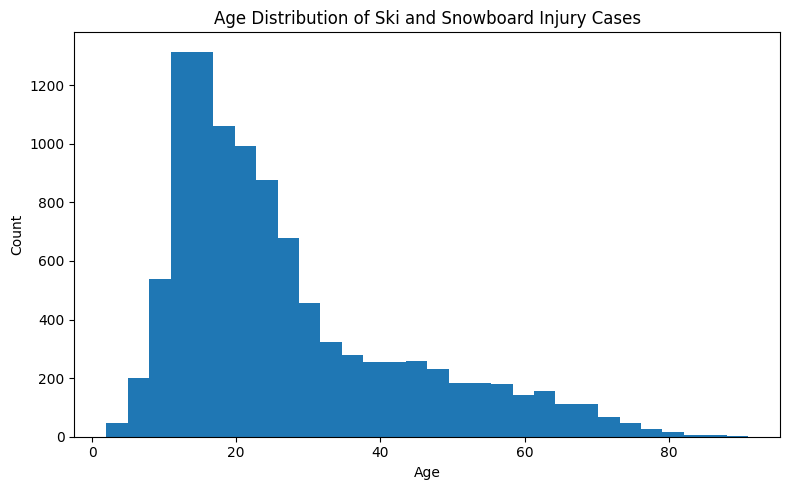

In [20]:
#Figure 1: Age distribution
plt.figure(figsize=(8,5))
df["Age"].dropna().plot(kind="hist", bins=30)
plt.title("Age Distribution of Ski and Snowboard Injury Cases")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 1 Interpretation:** The age distribution of injury cases is right-skewed, with the highest concentration of injuries occurring among adolescents and young adults. Injury counts decrease progressively with age, although cases are present across a wide age range. This pattern indicates that a substantial proportion of emergency department-treated ski and snowboard injuries occur among younger individuals in this dataset.

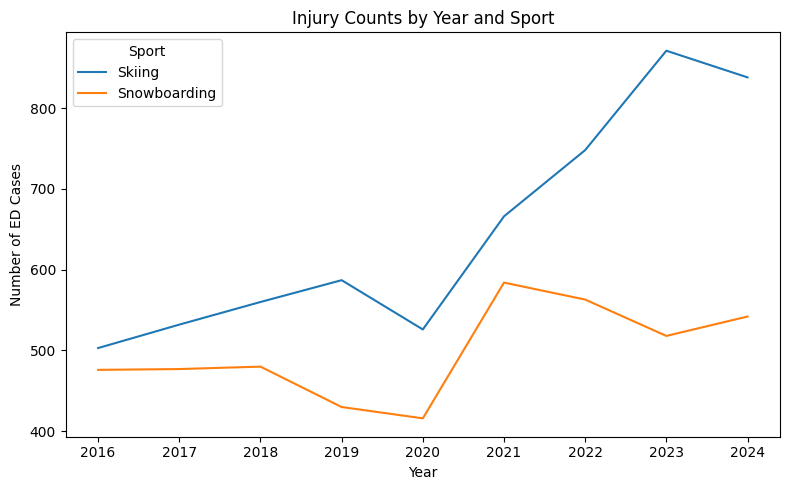

In [59]:
#Figure 2: Injury counts by year and sport
counts = df.groupby(["Year", "Sport"]).size().unstack("Sport").fillna(0)

counts.plot(figsize=(8,5))
plt.title("Injury Counts by Year and Sport")
plt.xlabel("Year")
plt.ylabel("Number of ED Cases")
plt.tight_layout()
plt.savefig("injury_counts_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 2 Interpretation:** Injury counts increased through the pre-pandemic years, declined in 2020, and then rose again afterward. Skiing consistently accounts for more observed emergency department cases than snowboarding in this dataset. The drop in 2020 likely reflects reduced snow sport participation during the COVID-19 pandemic rather than a true change in injury risk.

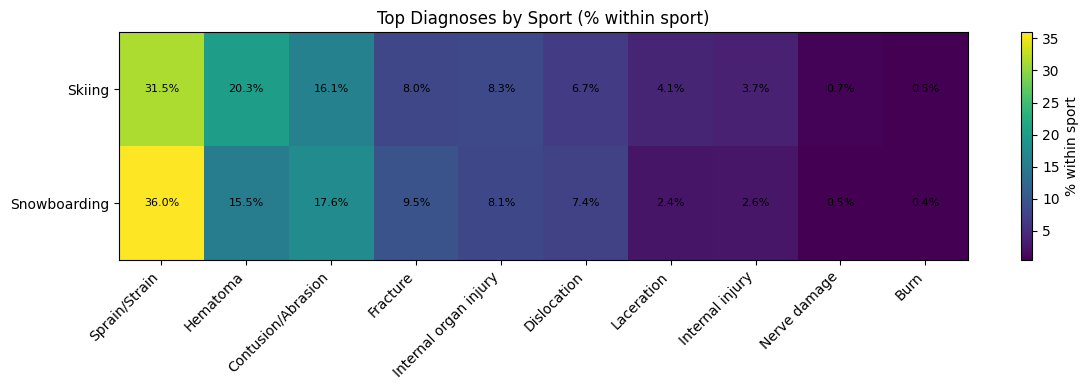

In [22]:
#Figure 3: Top diagnoses by sport heatmap
top_n = 10
top_diag = df["Diagnosis_Label"].value_counts().head(top_n).index

ct = pd.crosstab(df["Sport"], df["Diagnosis_Label"])[top_diag]
prop = ct.div(ct.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12,4))
plt.imshow(prop.values, aspect="auto")
plt.xticks(range(len(prop.columns)), prop.columns, rotation=45, ha="right")
plt.yticks(range(len(prop.index)), prop.index)
plt.colorbar(label="% within sport")
plt.title("Top Diagnoses by Sport (% within sport)")

for i in range(prop.shape[0]):
    for j in range(prop.shape[1]):
        plt.text(j, i, f"{prop.iloc[i, j]:.1f}%", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

**Figure 3 Interpretation:** Sprain/strain injuries account for the largest proportion of injuries in both skiing and snowboarding, representing approximately one-third of cases in each sport. Snowboarding shows a slightly higher proportion of fractures, while skiing has a higher proportion of hematomas. Contusions and abrasions occur at similar rates across both sports. Overall, the distributions suggest that while the general injury profiles are similar, certain injury types appear modestly more common in one sport than the other.

## 6. Statistical Testing

To assess whether injury patterns differ significantly between skiing and snowboarding, chi-square tests of independence were used for categorical comparisons. A significance threshold of p < 0.05 was used.

In [23]:
#Chi-square test: sport vs diagnosis
table_diag = pd.crosstab(df["Sport"], df["Diagnosis_Label"])
chi2_diag, p_diag, dof_diag, expected_diag = chi2_contingency(table_diag)

print("Sport vs Diagnosis_Label")
print("Chi-square statistic:", chi2_diag)
print("Degrees of freedom:", dof_diag)
print("p-value:", p_diag)

Sport vs Diagnosis_Label
Chi-square statistic: 93.19322659692287
Degrees of freedom: 9
p-value: 3.715999003290324e-16


In [24]:
#Chi-square test: sport vs severity
table_severity = pd.crosstab(df["Sport"], df["severe_flag"])
chi2_sev, p_sev, dof_sev, expected_sev = chi2_contingency(table_severity)

print("Sport vs severe_flag")
print("Chi-square statistic:", chi2_sev)
print("Degrees of freedom:", dof_sev)
print("p-value:", p_sev)

Sport vs severe_flag
Chi-square statistic: 142.99315043288385
Degrees of freedom: 1
p-value: 5.898322803763907e-33


### Statistical Testing Summary

Chi-square tests of independence showed that both diagnosis distribution and injury severity differed significantly between skiing and snowboarding. For diagnosis category, the association between sport and diagnosis was statistically significant, χ²(9) = 93.19, p < 0.001. Injury severity also differed significantly by sport, χ²(1) = 142.99, p < 0.001. These findings suggest that the distribution of injury types and the proportion of more severe injuries are not the same across the two sports.

## 7. Predictive Modeling

In addition to descriptive and inferential analysis, a predictive modeling task was performed to classify whether an injury occurred during the post-COVID period (1 = post-COVID, 0 = pre-COVID). This was treated as a binary classification problem using demographic and injury characteristics as predictors.

The purpose of this analysis was to evaluate whether injury patterns in the dataset changed meaningfully after the pandemic period. Logistic Regression was used as an interpretable baseline model, and Random Forest was used as a more flexible nonlinear model for comparison.

In [38]:
# Define pre- vs post-COVID modeling dataset
# Exclude 2020 as a transition year

df_model = df.copy()
df_model = df_model[df_model["Year"] != 2020].copy()

# Define post-COVID period
df_model["post_covid_period"] = (df_model["Year"] >= 2021).astype(int)

display(df_model["post_covid_period"].value_counts(dropna=False))
display(df_model["post_covid_period"].value_counts(normalize=True).round(3))

post_covid_period
1    5330
0    4045
Name: count, dtype: int64

post_covid_period
1    0.569
0    0.431
Name: proportion, dtype: float64

In [39]:
#Drop leakage columns
leak_cols = ["Treatment_Date", "Year", "CPSC_Case_Number"]
df_model = df_model.drop(columns=[c for c in leak_cols if c in df_model.columns], errors="ignore")

#Define features and target
target = "post_covid_period"
X = df_model.drop(columns=[target], errors="ignore")
y = df_model[target]

print("Remaining leakage columns in X:", [c for c in leak_cols if c in X.columns])
print("X shape:", X.shape)
print("y shape:", y.shape)

Remaining leakage columns in X: []
X shape: (9375, 29)
y shape: (9375,)


In [40]:
#Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [41]:
#Recompute feature lists from the current training set
num_features = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

#Safety check to ensure leakage columns are not included
leak_cols = ["Treatment_Date", "Year", "CPSC_Case_Number"]
num_features = [c for c in num_features if c not in leak_cols]
cat_features = [c for c in cat_features if c not in leak_cols]

print("Numeric features:", num_features)
print("Categorical features:", cat_features)

Numeric features: ['Age', 'Sex', 'Race', 'Hispanic', 'Body_Part', 'Diagnosis', 'Body_Part_2', 'Diagnosis_2', 'Disposition', 'Location', 'Fire_Involvement', 'Alcohol', 'Drug', 'Product_1', 'Product_2', 'Product_3', 'PSU', 'Weight', 'severe_flag']
Categorical features: ['Other_Race', 'Other_Diagnosis', 'Other_Diagnosis_2', 'Narrative_1', 'Stratum', 'Sport', 'Age_Group', 'Diagnosis_Label', 'Sex_Label', 'Body_Part_Label']


In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features),
])

### Baseline Model: Logistic Regression

Logistic Regression was used as a baseline classifier because it is simple, interpretable, and appropriate for binary classification. It provides a useful benchmark against which more complex models can be compared.

In [43]:
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

=== Baseline: Logistic Regression ===
Accuracy : 0.690
Precision: 0.732
Recall   : 0.718
F1-score : 0.725
ROC-AUC  : 0.748


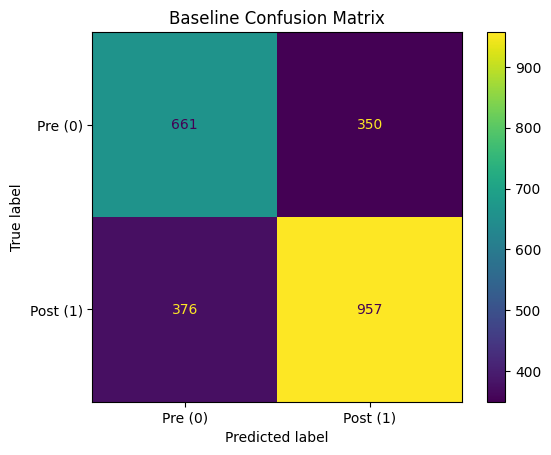

In [57]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

#Baseline predictions
y_pred_lr = baseline_model.predict(X_test)
y_proba_lr = baseline_model.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, zero_division=0)
rec_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print("=== Baseline: Logistic Regression ===")
print(f"Accuracy : {acc_lr:.3f}")
print(f"Precision: {prec_lr:.3f}")
print(f"Recall   : {rec_lr:.3f}")
print(f"F1-score : {f1_lr:.3f}")
print(f"ROC-AUC  : {auc_lr:.3f}")

cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=["Pre (0)", "Post (1)"]).plot(values_format="d")
plt.title("Baseline Confusion Matrix")
plt.savefig("confusion_matrix_lr.png", dpi=300, bbox_inches="tight")
plt.show()

### Baseline Model Interpretation

The Logistic Regression model serves as an interpretable baseline for classifying injuries into pre-COVID versus post-COVID periods. Its performance provides a reference point for evaluating whether a more flexible model can capture more complex shifts in injury patterns over time.

### Improved Model: Random Forest

A Random Forest classifier was used as an improved model because it can capture nonlinear relationships and interactions between predictors that Logistic Regression may miss.

In [45]:
from sklearn.ensemble import RandomForestClassifier

improved_model = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

improved_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

=== Improved: Random Forest ===
Accuracy : 0.815
Precision: 0.812
Recall   : 0.878
F1-score : 0.844
ROC-AUC  : 0.893


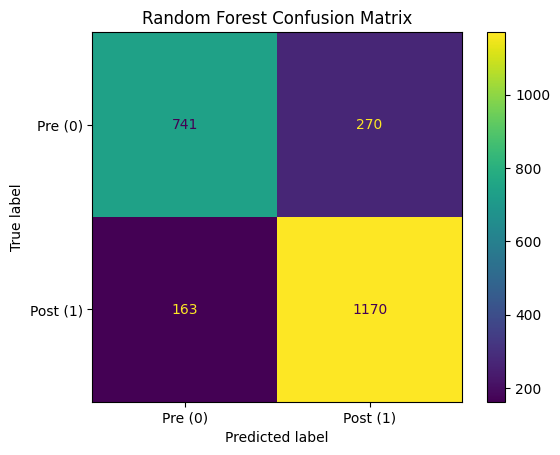

In [56]:
#Random Forest predictions
y_pred_rf = improved_model.predict(X_test)
y_proba_rf = improved_model.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print("=== Improved: Random Forest ===")
print(f"Accuracy : {acc_rf:.3f}")
print(f"Precision: {prec_rf:.3f}")
print(f"Recall   : {rec_rf:.3f}")
print(f"F1-score : {f1_rf:.3f}")
print(f"ROC-AUC  : {auc_rf:.3f}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=["Pre (0)", "Post (1)"]).plot(values_format="d")
plt.title("Random Forest Confusion Matrix")
plt.savefig("confusion_matrix_rf.png", dpi=300, bbox_inches="tight")
plt.show()

### Improved Model Interpretation

The Random Forest model was used to determine whether a more flexible classifier could better distinguish pre-COVID from post-COVID injury cases. Compared with the baseline model, it can account for more complex relationships among demographic and injury variables.

## 8. Model Comparison

In [48]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression (Baseline)", "Random Forest (Improved)"],
    "Accuracy": [acc_lr, acc_rf],
    "Precision": [prec_lr, prec_rf],
    "Recall": [rec_lr, rec_rf],
    "F1-Score": [f1_lr, f1_rf],
    "ROC-AUC": [auc_lr, auc_rf]
}).round(3)

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Baseline),0.690,0.732,0.718,0.725,0.748
1,Random Forest (Improved),0.815,0.812,0.878,0.844,0.893


### Model Comparison Interpretation

The comparison table summarizes model performance across multiple evaluation metrics. The better-performing model can be identified by considering not only overall accuracy, but also recall, F1-score, and ROC-AUC, which provide a fuller picture of predictive performance for a binary classification task.

## 9. Model Evaluation Visualizations

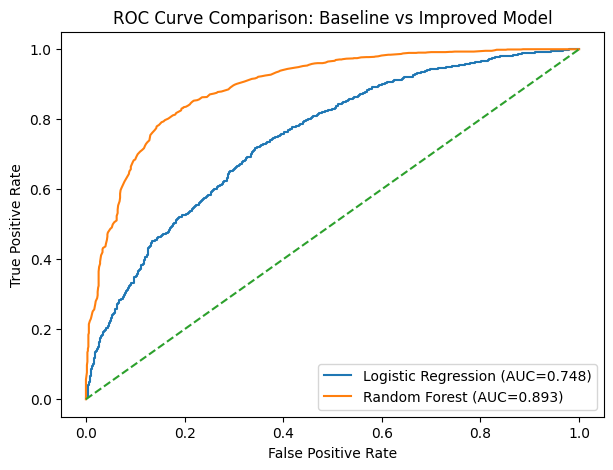

In [55]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

roc_auc_lr = auc(fpr_lr, tpr_lr)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Baseline vs Improved Model")
plt.legend()
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

**ROC Curve Interpretation:** The ROC curve compares each model’s ability to distinguish pre-COVID from post-COVID injury cases across all classification thresholds. A curve closer to the top-left corner and a larger ROC-AUC indicate better overall discrimination.

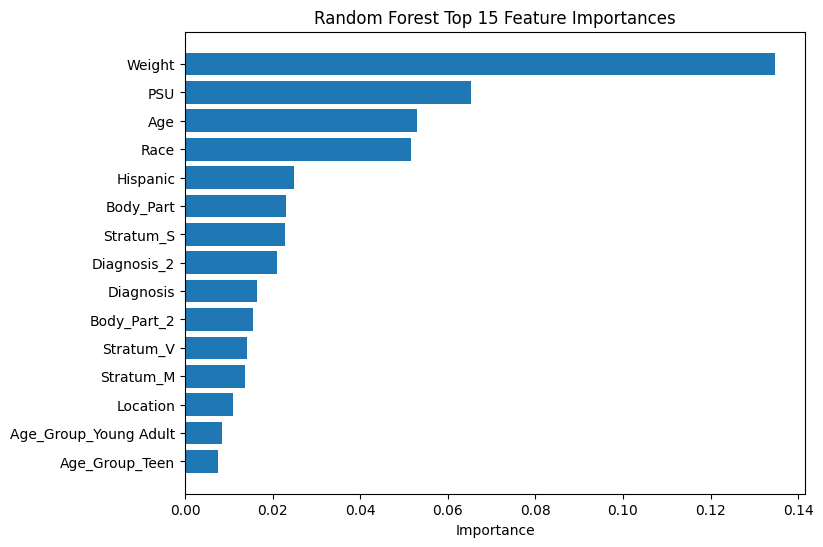

In [58]:
#Random Forest feature importance plot
preprocess_fitted = improved_model.named_steps["preprocess"]
rf_fitted = improved_model.named_steps["model"]

try:
    feature_names = preprocess_fitted.get_feature_names_out()
except Exception:
    feature_names = np.array([f"feature_{i}" for i in range(len(rf_fitted.feature_importances_))])

clean_feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in feature_names
]

importances = rf_fitted.feature_importances_

fi = pd.DataFrame({
    "feature": clean_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

top_n = 15
fi_top = fi.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(fi_top["feature"], fi_top["importance"])
plt.xlabel("Importance")
plt.title(f"Random Forest Top {top_n} Feature Importances")
plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

**Feature Importance Interpretation:** This plot shows which predictors contributed most to the Random Forest model when distinguishing pre-COVID from post-COVID injury cases. Feature importance does not imply causation, but it does indicate which variables the model relied on most heavily for classification.

## 10. Error Analysis and Modeling Limitations

Several limitations should be considered when interpreting the predictive modeling results. First, this analysis is observational and retrospective, so the models identify associations with the post-COVID period rather than causal effects. Second, some important predictors, such as survey design variables like Weight and PSU, may reflect structural aspects of the dataset rather than true clinical differences. Third, demographic variables such as Race, Age, and Hispanic ethnicity may partially capture broader disparities in healthcare access, documentation, or reporting patterns. Finally, because NEISS is limited to emergency department-treated injuries, the models do not generalize to injuries treated in other settings or to all participants in skiing and snowboarding.

## 11. Summary Tables

The following tables summarize key project findings in a format suitable for reporting.

In [31]:
#Map for Table 1
sex_map = {
    0: "Unknown",
    1: "Male",
    2: "Female"
}

df["Sex_Label"] = df["Sex"].map(sex_map)

In [32]:
# Table 1: Demographics by sport
table1 = pd.crosstab(df["Sport"], df["Sex_Label"], margins=True)
display(table1)

Sex_Label,Female,Male,Unknown,All
Sport,,,,
Skiing,2418,3411,2,5831
Snowboarding,1261,3225,0,4486
All,3679,6636,2,10317


In [35]:
#Table 2: Diagnosis distribution by sport (percent within sport)
table2 = pd.crosstab(df["Sport"], df["Diagnosis_Label"], normalize="index") * 100
display(table2.round(1))

Diagnosis_Label,Burn,Contusion/Abrasion,Dislocation,Fracture,Hematoma,Internal injury,Internal organ injury,Laceration,Nerve damage,Sprain/Strain
Sport,,,,,,,,,,
Skiing,0.5,16.1,6.7,8.0,20.3,3.7,8.3,4.1,0.7,31.5
Snowboarding,0.4,17.6,7.4,9.5,15.5,2.6,8.1,2.4,0.5,36.0


In [33]:
#NEISS body part code mapping
body_part_map = {
    30: "Shoulder",
    31: "Upper trunk",
    32: "Elbow",
    33: "Lower arm",
    34: "Wrist",
    35: "Hand/Finger",
    36: "Lower trunk",
    37: "Knee",
    38: "Lower leg",
    75: "Head",
    76: "Mouth",
    77: "Face",
    79: "Lower extremity",
    80: "Upper extremity",
    81: "Upper leg",
    82: "Foot",
    83: "Toe",
    85: "Neck",
    87: "Not recorded",
    88: "Pubic region",
    89: "Head/Neck",
    92: "Finger",
    93: "Toe",
    94: "Ear"
}

#Apply labels
df["Body_Part_Label"] = df["Body_Part"].map(body_part_map)

In [36]:
#Table 3: Body part distribution by sport (percent within sport)

table3 = pd.crosstab(
    df["Sport"],
    df["Body_Part_Label"],
    normalize="index"
) * 100

table3 = table3.drop(columns=["Not recorded"], errors="ignore")

display(table3.round(1))

Body_Part_Label,Ear,Elbow,Face,Finger,Foot,Hand/Finger,Head,Head/Neck,Knee,Lower arm,Lower extremity,Lower leg,Lower trunk,Mouth,Neck,Pubic region,Shoulder,Toe,Upper extremity,Upper leg,Upper trunk,Wrist
Sport,,,,,,,,,,,,,,,,,,,,,,
Skiing,0.2,1.5,0.2,3.3,1.3,18.9,16.2,2.4,3.0,2.3,7.1,0.2,9.9,2.7,0.4,1.0,11.5,1.0,2.3,2.5,7.2,4.8
Snowboarding,0.1,2.8,0.1,1.2,0.9,6.2,17.4,1.7,3.2,7.9,6.3,0.2,2.4,1.8,0.1,0.3,18.3,0.7,2.1,0.7,6.4,19.2


The distribution of injured body regions differed between skiing and snowboarding. In skiing, injuries most frequently involved the hand/finger, head, and shoulder regions, with additional concentration in the lower trunk and lower extremity. In snowboarding, wrist, shoulder, and head injuries were most common, and lower arm injuries were also more frequent than in skiing. Overall, these patterns suggest that upper extremity injuries are prominent in both sports, but snowboarding shows a stronger concentration in the wrist and lower arm, whereas skiing shows relatively more injuries involving the hand/finger and trunk.

## 12. Ethics, Bias, and Responsible Data Science

This project uses a publicly available, de-identified injury surveillance dataset, so no direct personal identifiers are included. However, responsible interpretation remains important because the NEISS database captures only injuries treated in emergency departments. This means the dataset may overrepresent more severe injuries and underrepresent injuries treated in urgent care settings or not treated medically at all.

The dataset is also cross-sectional and observational, which limits the ability to make causal claims. Any observed association between sport type and injury patterns should therefore be interpreted as descriptive rather than causal. Additional sources of bias may include coding variability across hospitals and limited contextual information about the injury mechanism.

## 13. Limitations

Several limitations should be considered when interpreting these findings. First, the NEISS dataset captures only emergency department-treated injuries, so the results do not represent all skiing and snowboarding injuries in the population. Second, the dataset contains limited clinical detail, which restricts more nuanced assessment of injury severity. Third, some variables, especially secondary injury fields, have structural missingness. Finally, because this analysis is based on observational surveillance data, it cannot establish causal relationships between sport participation and injury outcomes.

## 14. Conclusion

This project demonstrates that skiing and snowboarding injuries differ in meaningful ways across demographic and diagnostic patterns. Younger patients account for a substantial share of injuries, and diagnosis distributions vary by sport, with sprains/strains and fractures among the most common categories. Overall, the project highlights the value of injury surveillance data for describing patterns of risk while also underscoring the importance of careful interpretation, reproducible analysis, and responsible communication of findings.

In [53]:
#Save cleaned project dataset
output_path = "neiss_snow_2016_2024_m4_ready.csv"
df.to_csv(output_path, index=False)

print("Saved cleaned dataset to:", output_path)

Saved cleaned dataset to: neiss_snow_2016_2024_m4_ready.csv


## 15. Reproducibility Notes

This notebook documents the full workflow used for the project, including:

• Data loading from the NEISS dataset  
• Data cleaning and variable labeling  
• Exploratory data analysis and visualization  
• Statistical testing  
• Generation of summary tables

All figures and tables shown in the report are generated directly from this notebook.
Running the notebook sequentially will reproduce the full analysis.